# CAVS: Combined Cruise and Coast

This Connected Automated Vehicle (CAV) demo enables both IDM eco-cruise
and eco-coast simultaneously. The plots include a coast-mode indicator
showing when the vehicle is coasting.

In [1]:
import os

import numpy as np
import seaborn as sns

import sys
from pathlib import Path

sys.path.insert(0, str(next(p / "demo_scripts" for p in (Path.cwd(), *Path.cwd().parents) if (p / "demo_scripts").is_dir())))

import fastsim as fsim
from plot_utils import plot_speed_by_time, plot_speed_by_dist

In [2]:
sns.set_theme()

SHOW_PLOTS = os.environ.get("SHOW_PLOTS", "true").lower() == "true"
SAVE_FIGS = os.environ.get("SAVE_FIGS", "false").lower() == "true"

## Setup

In [3]:
veh = fsim.Vehicle.from_resource("2012_Ford_Fusion.yaml")
veh.set_save_interval(1)

cyc = fsim.Cycle.from_resource("udds.csv")
end_idle_duration_s = cyc.ending_idle_time_s()
cyc = cyc.extend_time(absolute_time_s=120.0, time_fraction=0.25)
cyc0 = cyc.copy()
vavg = cyc0.average_speed_m_per_s(while_moving=True)

## Configure Combined Parameters

Both coasting and IDM parameters are enabled on the same `Maneuver`.

In [4]:
man = fsim.Maneuver.create_from(cyc, veh.copy())
d = man.to_pydict()

# Coasting parameters
d["coast_allow"] = True
d["coast_brake_start_speed_meters_per_second"] = 8.9408  # 20 mph
d["coast_brake_accel_meters_per_second_squared"] = -2.5
d["favor_grade_accuracy"] = True
d["coast_allow_passing"] = True
d["coast_max_speed_meters_per_second"] = 33.5280  # 75 mph
d["coast_time_horizon_for_adjustment_seconds"] = 120.0

# IDM parameters
d["idm_allow"] = True
d["idm_desired_speed_meters_per_second"] = vavg
d["idm_headway_seconds"] = 1.0
d["idm_minimum_gap_meters"] = 1.0
d["idm_delta"] = 4.0
d["idm_acceleration_meters_per_second_squared"] = 1.0
d["idm_deceleration_meters_per_second_squared"] = 2.5

man = fsim.Maneuver.from_pydict(d)
cyc = man.apply_maneuvers()
cyc_for_coast = cyc.copy()
cyc = cyc.trim_ending_idle(idle_to_keep_s=end_idle_duration_s)

In [5]:
sd = fsim.SimDrive(veh, cyc)
sd.walk()

## Results

Original cycle speed vs. achieved speed with both cruise and coast. The
red dotted line indicates when coast mode is active.

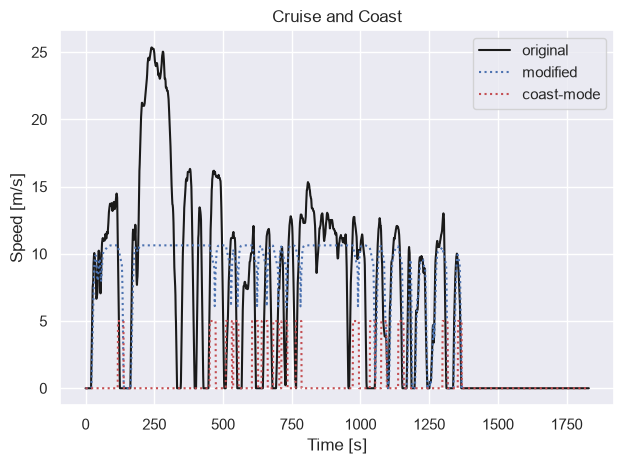

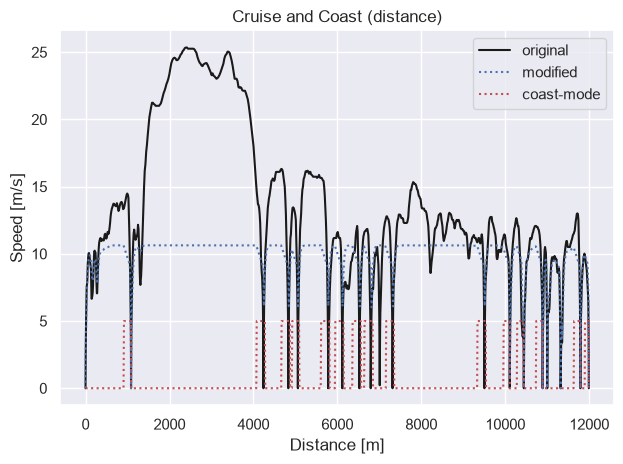

In [6]:
if SHOW_PLOTS:
    c0 = cyc0.to_pydict()
    df = sd.to_dataframe()
    is_coast = np.array(man.is_coasting()) * 5.0
    cd = cyc_for_coast.to_pydict()
    dist = cd["dist_meters"]
    is_coast_d = [
        np.interp(d, dist, is_coast)
        for d in df["cyc.dist_meters"]
    ]
    plot_speed_by_time(df, c0, is_coast, title="Cruise and Coast",
                       save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)
    plot_speed_by_dist(df, c0, is_coast_d, title="Cruise and Coast (distance)",
                       save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)